<a href="https://colab.research.google.com/github/sd1977/STIXBert/blob/master/notebooks/stixbert_pov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STIXBert: Self-Supervised STIX Graph Foundation Model

**Goal**: Pre-train a Heterogeneous Graph Transformer (HGT) on STIX 2.1
threat intelligence graphs using three self-supervised objectives:
1. Masked node prediction (GraphMAE-style)
2. Link prediction
3. Temporal ordering

**Architecture**: Frozen SentenceTransformer → **STIX Field Attention** (learnable MHA over 6 structured fields: name, description, pattern, kill_chain, type, labels) → HGT encoder.

**Data sources**: MITRE ATT&CK (enterprise/mobile/ics), ThreatFox, DigitalSide (500 bundles), URLhaus, MalwareBazaar, Feodo Tracker, CISA KEV. SDO + SCO node types enabled.

**Runtime**: Select GPU (T4 for dev, A100 for full training)

> **Two versions of this project exist:**
> - `src/` — importable Python package for local dev & production
> - This notebook — fully self-contained for Colab (no imports from `src/`)

## 1. Setup — Install, Mount Drive, Configure

In [41]:
# Install dependencies
!pip install -q torch-geometric stix2 taxii2-client sentence-transformers \
    scikit-learn umap-learn matplotlib hdbscan huggingface_hub

import os, sys, json, random, logging
from pathlib import Path
from collections import defaultdict
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()} "
      f"({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'})")

# --- Mount Google Drive (data, checkpoints, results persist here) ---
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = Path('/content/drive/MyDrive/stixbert')
PATHS = {
    'raw_mitre':       DRIVE_ROOT / 'data/raw/mitre_attack',
    'raw_threatfox':   DRIVE_ROOT / 'data/raw/threatfox',
    'raw_digitalside': DRIVE_ROOT / 'data/raw/digitalside',
    'raw_urlhaus':     DRIVE_ROOT / 'data/raw/urlhaus',
    'raw_malwarebazaar': DRIVE_ROOT / 'data/raw/malwarebazaar',
    'raw_feodo':       DRIVE_ROOT / 'data/raw/feodo',
    'raw_cisa_kev':    DRIVE_ROOT / 'data/raw/cisa_kev',
    'processed':       DRIVE_ROOT / 'data/processed',
    'train':           DRIVE_ROOT / 'data/train',
    'test':            DRIVE_ROOT / 'data/test',
    'eval':            DRIVE_ROOT / 'data/eval',
    'checkpoints':     DRIVE_ROOT / 'checkpoints',
    'results':         DRIVE_ROOT / 'results',
}
for p in PATHS.values():
    p.mkdir(parents=True, exist_ok=True)

# --- Configuration (single dict — no external files needed) ---
CFG = {
    'model': {
        'name': 'stixbert', 'version': '0.1.0',
        # Architecture rationale: 4 heads / 4 layers / 128d is a standard
        # baseline for small-to-mid heterogeneous graphs (cf. OGB-LSC, HGB
        # benchmarks). We start conservative and sweep via grid_search.
        'input_dim': 128,         # matches text projection dim
        'hidden_dim': 128,        # [64, 128, 256] swept in grid search
        'output_dim': 128,
        'num_heads': 4,           # [2, 4, 8] swept in grid search
        'num_layers': 4,          # [2, 4, 6] swept in grid search
        'dropout': 0.1,           # [0.05, 0.1, 0.2] swept in grid search
        'text_model': 'all-MiniLM-L6-v2',
        'max_seq_length': 256,    # max tokens for text feature encoding
    },
    'training': {
        'num_epochs': 200,        # Phase 2: full training with best HPs (early stopping will halt)
        'batch_size': 64,         # default; overridden by HP search result
        'eval_batch_size': 128,
        'lr': 1e-3,              # default; overridden by HP search result
        'weight_decay': 1e-4,
        'mask_ratio': 0.15,       # default; overridden by HP search result
        'grad_clip_norm': 1.0,
        'gradient_accumulation_steps': 1,
        'log_every': 5,
        'seed': 42,
        'early_stopping': {
            'enabled': True, 'patience': 30, 'min_delta': 5e-4,
        },
        'loss_weights': {'masked_node': 1.0, 'link_pred': 1.0, 'temporal': 0.3},
    },
    'cv': {
        'num_folds': 5,           # 5-fold CV for HP search
        'stratify_by': 'node_type',
    },
    'grid_search': {
        'enabled': True,
        'strategy': 'random',     # random search more efficient than grid for >3 params
        'n_trials': 20,           # number of HP combos to try
        'search_epochs': 5,       # short runs to evaluate each combo
        'parameters': {
            'hidden_dim': [64, 128, 256],
            'num_heads': [2, 4, 8],
            'num_layers': [2, 4, 6],
            'lr': [5e-4, 1e-3, 2e-3],
            'batch_size': [32, 64, 128],
            'mask_ratio': [0.10, 0.15, 0.25],
            'dropout': [0.05, 0.1, 0.2],
        },
        'metric': 'total_loss',
        'direction': 'minimize',
    },
    'class_imbalance': {
        # STIX graphs are skewed: many indicators/relationships, few campaigns/intrusion-sets.
        'analysis': True,         # log per-type class distribution before training
        'strategy': 'weighted',   # weighted | focal | oversample | none
        'focal_gamma': 2.0,       # only used if strategy='focal'
    },
    'finetune': {
        'attack_classification': {'epochs': 30, 'lr': 1e-3, 'freeze_encoder': False},
        'label_efficiency_fractions': [0.01, 0.05, 0.1, 0.25, 0.5, 1.0],
    },
    'optimization': {
        'optimizer': 'adamw',
        'scheduler': 'cosine',    # cosine annealing with warmup
        'warmup_epochs': 10,
        'min_lr': 1e-6,
        'mixed_precision': True,  # torch.cuda.amp on A100
    },
    'huggingface': {
        'repo_id': 'shidey/stixbert', 'private': True,
        'tags': ['threat-intelligence', 'stix', 'graph-neural-network',
                 'hgt', 'cybersecurity'],
    },
}

# --- Reproducibility ---
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(name)s %(levelname)s: %(message)s',
)
logger = logging.getLogger('stixbert')

print(f"\nDrive root: {DRIVE_ROOT}")
print(f"Device: {DEVICE} | Seed: {SEED}")
m = CFG['model']
print(f"Model: {m['hidden_dim']}d, {m['num_heads']} heads, {m['num_layers']} layers")
t = CFG['training']
print(f"Pre-train: {t['num_epochs']} epochs (Phase 2), lr={t['lr']}, batch_size={t['batch_size']}")
gs = CFG['grid_search']
print(f"HP Search: {gs['n_trials']} trials × {gs['search_epochs']} epochs × {CFG['cv']['num_folds']}-fold CV")
print(f"Class imbalance strategy: {CFG['class_imbalance']['strategy']}")

PyTorch: 2.10.0+cu128
CUDA: True (NVIDIA A100-SXM4-40GB)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Drive root: /content/drive/MyDrive/stixbert
Device: cuda | Seed: 42
Model: 128d, 4 heads, 4 layers
Pre-train: 200 epochs (Phase 2), lr=0.001, batch_size=64
HP Search: 20 trials × 5 epochs × 5-fold CV
Class imbalance strategy: weighted


## 2. Data Retrieval — MITRE ATT&CK, ThreatFox, DigitalSide, URLhaus, MalwareBazaar, Feodo, CISA KEV

In [42]:
# ── Uncomment to force full re-run (deletes all cached artifacts) ─────
# import pathlib
# caches = {
#     'STIX bundles':  pathlib.Path(PATHS['processed']) / 'stix_bundles.pkl',
#     'HeteroData':    pathlib.Path(PATHS['processed']) / 'hetero_data.pt',
#     'Best checkpoint': pathlib.Path(PATHS['checkpoints']) / 'stixbert_best.pt',
# }
# for name, path in caches.items():
#     if path.exists():
#         path.unlink()
#         print(f'✓ Deleted {name}: {path}')
#     else:
#         print(f'  {name}: not found (already clean)')

In [43]:
import urllib.request
import urllib.parse
import urllib.error
import pickle

# ── abuse.ch Auth-Key (free at https://auth.abuse.ch/) ────────────────
import os
ABUSE_CH_KEY = os.environ.get('ABUSE_CH_KEY')
if not ABUSE_CH_KEY:
    try:
        from google.colab import userdata
        ABUSE_CH_KEY = userdata.get('ABUSE_CH_KEY')
    except Exception:
        pass
if ABUSE_CH_KEY:
    logger.info(f'ABUSE_CH_KEY loaded (…{ABUSE_CH_KEY[-6:]})')
else:
    logger.warning('ABUSE_CH_KEY not set — abuse.ch feeds will fail. '
                   'Get a free key at https://auth.abuse.ch/ and set it as '
                   'env var or Colab Secret.')

_STIX_CACHE = PATHS['processed'] / 'stix_bundles.pkl'

if _STIX_CACHE.exists():
    logger.info(f'Loading cached STIX bundles from {_STIX_CACHE}')
    with open(_STIX_CACHE, 'rb') as f:
        _cache = pickle.load(f)
    bundles = _cache['bundles']
    threatfox_stix = _cache['threatfox_stix']
    digitalside_bundles = _cache['digitalside_bundles']
    urlhaus_stix = _cache['urlhaus_stix']
    bazaar_stix = _cache['bazaar_stix']
    feodo_stix = _cache['feodo_stix']
    kev_stix = _cache['kev_stix']
    print(f'✓ Loaded cached STIX data ({len(bundles)} ATT&CK bundles, '
          f'{len(digitalside_bundles)} DigitalSide bundles)')
else:
    # ── MITRE ATT&CK ────────────────────────────────────────────────────
    ATTACK_URLS = {
        'enterprise': 'https://raw.githubusercontent.com/mitre-attack/attack-stix-data/master/enterprise-attack/enterprise-attack.json',
        'mobile':     'https://raw.githubusercontent.com/mitre-attack/attack-stix-data/master/mobile-attack/mobile-attack.json',
        'ics':        'https://raw.githubusercontent.com/mitre-attack/attack-stix-data/master/ics-attack/ics-attack.json',
    }

    def download_attack_bundle(domain, output_dir):
        dest = output_dir / f'{domain}-attack.json'
        if dest.exists():
            logger.info(f'Using cached: {dest}')
            with open(dest) as f: return json.load(f)
        logger.info(f'Downloading ATT&CK {domain}...')
        urllib.request.urlretrieve(ATTACK_URLS[domain], dest)
        with open(dest) as f: return json.load(f)

    bundles = []
    for domain in ['enterprise', 'mobile', 'ics']:
        b = download_attack_bundle(domain, PATHS['raw_mitre'])
        bundles.append(b)
        types = {}
        for obj in b.get('objects', []):
            t = obj.get('type', 'unknown')
            types[t] = types.get(t, 0) + 1
        total = sum(types.values())
        print(f"\nATT&CK {domain}: {total} objects")
        for t, c in sorted(types.items(), key=lambda x: -x[1])[:8]:
            print(f"  {t}: {c}")

    # ── ThreatFox ────────────────────────────────────────────────────────
    THREATFOX_API_URL = 'https://threatfox-api.abuse.ch/api/v1/'

    def fetch_threatfox_iocs(days=7):
        logger.info(f'Fetching ThreatFox recent IOCs (API, days={days})...')
        body = json.dumps({'query': 'get_iocs', 'days': days}).encode()
        headers = {}
        if ABUSE_CH_KEY:
            headers['Auth-Key'] = ABUSE_CH_KEY
        req = urllib.request.Request(THREATFOX_API_URL, data=body, headers=headers)
        try:
            with urllib.request.urlopen(req, timeout=60) as resp:
                raw = json.loads(resp.read())
        except urllib.error.HTTPError as e:
            body_text = e.read().decode('utf-8', 'ignore')[:500]
            logger.warning(f'ThreatFox API HTTP {e.code}: {body_text}')
            return []
        except Exception as e:
            logger.warning(f'ThreatFox fetch failed: {e}')
            return []
        iocs = raw.get('data', []) if isinstance(raw, dict) else raw
        if not isinstance(iocs, list):
            iocs = []
        out = PATHS['raw_threatfox'] / 'threatfox_recent.json'
        with open(out, 'w') as f: json.dump(iocs, f, indent=2)
        logger.info(f'ThreatFox: fetched {len(iocs)} IOCs')
        return iocs

    def threatfox_to_stix(iocs):
        from stix2 import Bundle, Indicator, Malware, Relationship
        stix_objects, malware_cache = [], {}
        for ioc in iocs:
            ioc_type = ioc.get('ioc_type', '')
            ioc_value = ioc.get('ioc', '').strip()
            if not ioc_value:
                continue
            malware_name = ioc.get('malware_printable', '')
            threat_type = ioc.get('threat_type', '')
            pattern = None
            if 'ip' in ioc_type.lower():
                pattern = f"[ipv4-addr:value = '{ioc_value.split(':')[0]}']"
            elif 'domain' in ioc_type.lower():
                pattern = f"[domain-name:value = '{ioc_value}']"
            elif 'url' in ioc_type.lower():
                pattern = f"[url:value = '{ioc_value}']"
            elif 'md5' in ioc_type.lower():
                pattern = f"[file:hashes.MD5 = '{ioc_value}']"
            elif 'sha256' in ioc_type.lower():
                pattern = f"[file:hashes.'SHA-256' = '{ioc_value}']"
            if not pattern:
                continue
            indicator = Indicator(
                name=f'ThreatFox: {ioc_value}', pattern=pattern, pattern_type='stix',
                valid_from=ioc.get('first_seen_utc', '').replace(' ', 'T') + 'Z'
                    if ioc.get('first_seen_utc') else datetime.now().strftime('%Y-%m-%dT%H:%M:%SZ'),
                labels=[threat_type] if threat_type else ['malicious-activity'],
            )
            stix_objects.append(indicator)
            if malware_name and malware_name not in malware_cache:
                mw = Malware(name=malware_name, is_family=True,
                             malware_types=['unknown'])
                malware_cache[malware_name] = mw
                stix_objects.append(mw)
            if malware_name and malware_name in malware_cache:
                stix_objects.append(Relationship(
                    source_ref=indicator.id,
                    target_ref=malware_cache[malware_name].id,
                    relationship_type='indicates',
                ))
        return json.loads(Bundle(objects=stix_objects).serialize())

    threatfox_iocs = fetch_threatfox_iocs()
    threatfox_stix = threatfox_to_stix(threatfox_iocs) if threatfox_iocs else {'objects': []}
    print(f'\nThreatFox -> STIX: {len(threatfox_stix.get("objects", []))} objects')

    # ── DigitalSide ──────────────────────────────────────────────────────
    DIGITALSIDE_API = ('https://api.github.com/repos/davidonzo/'
                       'Threat-Intel/contents/stix2')
    DIGITALSIDE_RAW = ('https://raw.githubusercontent.com/'
                       'davidonzo/Threat-Intel/master/stix2/')
    MAX_DIGITALSIDE_BUNDLES = 500

    def fetch_digitalside_stix(max_bundles=MAX_DIGITALSIDE_BUNDLES):
        logger.info('Listing DigitalSide stix2/ via GitHub API...')
        req = urllib.request.Request(DIGITALSIDE_API,
                                    headers={'Accept': 'application/vnd.github.v3+json'})
        with urllib.request.urlopen(req) as resp:
            listing = json.loads(resp.read())
        json_files = [f['name'] for f in listing
                      if isinstance(f, dict) and f.get('name', '').endswith('.json')]
        logger.info(f'Found {len(json_files)} STIX bundles; downloading {max_bundles}')
        bundles = []
        for fname in json_files[:max_bundles]:
            url = f'{DIGITALSIDE_RAW}{fname}'
            dest = PATHS['raw_digitalside'] / fname
            try:
                urllib.request.urlretrieve(url, dest)
                with open(dest) as f: bundle = json.load(f)
                bundles.append(bundle)
            except Exception as e:
                logger.warning(f'Failed: {fname}: {e}')
        logger.info(f'DigitalSide: loaded {len(bundles)} STIX bundles')
        return bundles

    digitalside_bundles = fetch_digitalside_stix()
    total_ds_objs = sum(len(b.get('objects', [])) for b in digitalside_bundles)
    print(f'DigitalSide: {len(digitalside_bundles)} bundles, '
          f'{total_ds_objs} total objects')

    # ── URLhaus (abuse.ch) ───────────────────────────────────────────────
    def fetch_urlhaus_stix(limit=1000):
        from stix2 import Bundle, Indicator, Malware, Relationship
        logger.info(f'Fetching URLhaus recent URLs (limit={limit})...')
        url = f'https://urlhaus-api.abuse.ch/v1/urls/recent/limit/{limit}/'
        headers = {}
        if ABUSE_CH_KEY:
            headers['Auth-Key'] = ABUSE_CH_KEY
        req = urllib.request.Request(url, headers=headers, method='GET')
        try:
            with urllib.request.urlopen(req, timeout=60) as resp:
                raw = json.loads(resp.read())
        except urllib.error.HTTPError as e:
            body_text = e.read().decode('utf-8', 'ignore')[:500]
            logger.warning(f'URLhaus API HTTP {e.code}: {body_text}')
            return {'objects': []}
        except Exception as e:
            logger.warning(f'URLhaus fetch failed: {e}')
            return {'objects': []}

        urls = raw.get('urls', []) if isinstance(raw, dict) else raw
        if isinstance(urls, dict):
            urls = list(urls.values())

        stix_objects, malware_cache, skipped = [], {}, 0
        for entry in urls:
            url_val = entry.get('url', '').strip() if isinstance(entry, dict) else str(entry).strip()
            if not url_val:
                skipped += 1; continue
            tags = entry.get('tags', []) if isinstance(entry, dict) else []
            threat = entry.get('threat', '') if isinstance(entry, dict) else ''
            pattern = f"[url:value = '{url_val}']"
            ts = entry.get('dateadded', '') if isinstance(entry, dict) else ''
            valid_from = ts.replace(' ', 'T') + 'Z' if ts else datetime.now().strftime('%Y-%m-%dT%H:%M:%SZ')
            try:
                ind = Indicator(
                    name=f'URLhaus: {url_val[:80]}', pattern=pattern,
                    pattern_type='stix', valid_from=valid_from,
                    labels=tags[:3] if tags else ['malicious-activity'],
                )
            except Exception:
                skipped += 1; continue
            stix_objects.append(ind)
            mw_name = threat or (tags[0] if tags else '')
            if mw_name and mw_name not in malware_cache:
                mw = Malware(name=mw_name, is_family=True, malware_types=['unknown'])
                malware_cache[mw_name] = mw
                stix_objects.append(mw)
            if mw_name and mw_name in malware_cache:
                stix_objects.append(Relationship(
                    source_ref=ind.id, target_ref=malware_cache[mw_name].id,
                    relationship_type='indicates',
                ))
        logger.info(f'URLhaus: {len(stix_objects)} STIX objects ({skipped} skipped)')
        return json.loads(Bundle(objects=stix_objects).serialize()) if stix_objects else {'objects': []}

    urlhaus_stix = fetch_urlhaus_stix()
    print(f'\nURLhaus -> STIX: {len(urlhaus_stix.get("objects", []))} objects')

    # ── MalwareBazaar (abuse.ch) ─────────────────────────────────────────
    BAZAAR_URL = 'https://mb-api.abuse.ch/api/v1/'

    def fetch_malwarebazaar_stix(limit=500):
        from stix2 import Bundle, Indicator, Malware, Relationship
        logger.info(f'Fetching MalwareBazaar recent samples (limit={limit})...')
        data = urllib.parse.urlencode({'query': 'get_recent', 'selector': str(limit)}).encode()
        headers = {}
        if ABUSE_CH_KEY:
            headers['Auth-Key'] = ABUSE_CH_KEY
        req = urllib.request.Request(BAZAAR_URL, data=data, headers=headers)
        try:
            with urllib.request.urlopen(req, timeout=60) as resp:
                raw = json.loads(resp.read())
        except urllib.error.HTTPError as e:
            body_text = e.read().decode('utf-8', 'ignore')[:500]
            logger.warning(f'MalwareBazaar API HTTP {e.code}: {body_text}')
            return {'objects': []}
        except Exception as e:
            logger.warning(f'MalwareBazaar fetch failed: {e}')
            return {'objects': []}
        samples = raw.get('data', [])
        if not isinstance(samples, list):
            return {'objects': []}

        stix_objects, malware_cache, skipped = [], {}, 0
        for sample in samples:
            sha256 = sample.get('sha256_hash', '').strip()
            if not sha256:
                skipped += 1; continue
            pattern = f"[file:hashes.'SHA-256' = '{sha256}']"
            ts = sample.get('first_seen', '')
            valid_from = ts.replace(' ', 'T') + 'Z' if ts else datetime.now().strftime('%Y-%m-%dT%H:%M:%SZ')
            try:
                ind = Indicator(
                    name=f'MalwareBazaar: {sha256[:16]}...', pattern=pattern,
                    pattern_type='stix', valid_from=valid_from,
                    labels=[sample.get('file_type', 'unknown')],
                )
            except Exception:
                skipped += 1; continue
            stix_objects.append(ind)
            sig = sample.get('signature', '') or (sample.get('tags', [''])[0] if sample.get('tags') else '')
            if sig and sig not in malware_cache:
                mw = Malware(name=sig, is_family=True, malware_types=['unknown'])
                malware_cache[sig] = mw
                stix_objects.append(mw)
            if sig and sig in malware_cache:
                stix_objects.append(Relationship(
                    source_ref=ind.id, target_ref=malware_cache[sig].id,
                    relationship_type='indicates',
                ))
        logger.info(f'MalwareBazaar: {len(stix_objects)} objects ({skipped} skipped)')
        return json.loads(Bundle(objects=stix_objects).serialize()) if stix_objects else {'objects': []}

    bazaar_stix = fetch_malwarebazaar_stix()
    print(f'MalwareBazaar -> STIX: {len(bazaar_stix.get("objects", []))} objects')

    # ── Feodo Tracker (abuse.ch) — botnet C2 infrastructure ──────────────
    FEODO_URL = 'https://feodotracker.abuse.ch/downloads/ipblocklist_recommended.json'

    def fetch_feodo_stix():
        from stix2 import Bundle, Indicator, Infrastructure, Malware, Relationship
        logger.info('Fetching Feodo Tracker C2 blocklist...')
        req = urllib.request.Request(FEODO_URL)
        try:
            with urllib.request.urlopen(req, timeout=30) as resp:
                entries = json.loads(resp.read())
        except Exception as e:
            logger.warning(f'Feodo Tracker fetch failed: {e}')
            return {'objects': []}
        if not isinstance(entries, list):
            return {'objects': []}

        stix_objects, infra_cache, mw_cache = [], {}, {}
        for entry in entries:
            ip = entry.get('ip_address', '').strip() if isinstance(entry, dict) else ''
            if not ip:
                continue
            port = entry.get('port', '')
            malware_name = entry.get('malware', 'unknown')
            ts = entry.get('first_seen', '')
            valid_from = ts.replace(' ', 'T') + 'Z' if ts else datetime.now().strftime('%Y-%m-%dT%H:%M:%SZ')
            pattern = f"[ipv4-addr:value = '{ip}']"
            try:
                ind = Indicator(
                    name=f'Feodo C2: {ip}:{port}', pattern=pattern,
                    pattern_type='stix', valid_from=valid_from,
                    labels=['botnet', 'c2'],
                )
            except Exception:
                continue
            stix_objects.append(ind)
            infra_key = f'{ip}:{port}'
            if infra_key not in infra_cache:
                infra = Infrastructure(
                    name=f'C2: {ip}:{port}',
                    infrastructure_types=['command-and-control'],
                )
                infra_cache[infra_key] = infra
                stix_objects.append(infra)
            stix_objects.append(Relationship(
                source_ref=ind.id, target_ref=infra_cache[infra_key].id,
                relationship_type='indicates',
            ))
            if malware_name and malware_name not in mw_cache:
                mw = Malware(name=malware_name, is_family=True, malware_types=['botnet'])
                mw_cache[malware_name] = mw
                stix_objects.append(mw)
            if malware_name and malware_name in mw_cache:
                stix_objects.append(Relationship(
                    source_ref=infra_cache[infra_key].id,
                    target_ref=mw_cache[malware_name].id,
                    relationship_type='communicates_with',
                ))
        logger.info(f'Feodo Tracker: {len(stix_objects)} objects')
        return json.loads(Bundle(objects=stix_objects).serialize()) if stix_objects else {'objects': []}

    feodo_stix = fetch_feodo_stix()
    print(f'Feodo Tracker -> STIX: {len(feodo_stix.get("objects", []))} objects')

    # ── CISA Known Exploited Vulnerabilities ─────────────────────────────
    CISA_KEV_URL = 'https://www.cisa.gov/sites/default/files/feeds/known_exploited_vulnerabilities.json'

    def fetch_cisa_kev_stix():
        from stix2 import Bundle, Vulnerability
        logger.info('Fetching CISA Known Exploited Vulnerabilities...')
        req = urllib.request.Request(CISA_KEV_URL)
        try:
            with urllib.request.urlopen(req, timeout=30) as resp:
                raw = json.loads(resp.read())
        except Exception as e:
            logger.warning(f'CISA KEV fetch failed: {e}')
            return {'objects': []}
        vulns = raw.get('vulnerabilities', [])
        stix_objects = []
        for v in vulns:
            cve = v.get('cveID', '').strip()
            if not cve:
                continue
            name = v.get('vulnerabilityName', cve)
            desc = v.get('shortDescription', '')
            try:
                vuln = Vulnerability(
                    name=f'{cve}: {name}',
                    description=desc[:500] if desc else f'CISA KEV: {cve}',
                    external_references=[{
                        'source_name': 'cve', 'external_id': cve,
                        'url': f'https://nvd.nist.gov/vuln/detail/{cve}',
                    }],
                )
            except Exception:
                continue
            stix_objects.append(vuln)
        logger.info(f'CISA KEV: {len(stix_objects)} vulnerability objects')
        return json.loads(Bundle(objects=stix_objects).serialize()) if stix_objects else {'objects': []}

    kev_stix = fetch_cisa_kev_stix()
    print(f'CISA KEV -> STIX: {len(kev_stix.get("objects", []))} objects')

    # ── Cache all bundles ────────────────────────────────────────────────
    with open(_STIX_CACHE, 'wb') as f:
        pickle.dump({
            'bundles': bundles,
            'threatfox_stix': threatfox_stix,
            'digitalside_bundles': digitalside_bundles,
            'urlhaus_stix': urlhaus_stix,
            'bazaar_stix': bazaar_stix,
            'feodo_stix': feodo_stix,
            'kev_stix': kev_stix,
        }, f)
    print(f'\n✓ STIX bundles cached to {_STIX_CACHE}')

print(f'\n{"="*50}')
print(f'Total sources: ATT&CK (3) + ThreatFox + DigitalSide ({len(digitalside_bundles)})'
      f' + URLhaus + MalwareBazaar + Feodo + CISA KEV')
print(f'\nAll raw data cached under: {DRIVE_ROOT}/data/raw/')


ATT&CK enterprise: 24772 objects
  relationship: 20048
  x-mitre-analytic: 1739
  attack-pattern: 835
  malware: 696
  x-mitre-detection-strategy: 691
  course-of-action: 268
  intrusion-set: 187
  x-mitre-data-component: 109

ATT&CK mobile: 2536 objects
  relationship: 1811
  x-mitre-analytic: 211
  attack-pattern: 190
  x-mitre-detection-strategy: 124
  malware: 121
  x-mitre-data-component: 17
  intrusion-set: 17
  course-of-action: 15

ATT&CK ics: 1826 objects
  relationship: 1373
  attack-pattern: 95
  x-mitre-detection-strategy: 83
  x-mitre-analytic: 82
  course-of-action: 52
  x-mitre-data-component: 36
  malware: 30
  x-mitre-asset: 18

ThreatFox -> STIX: 6143 objects
DigitalSide: 500 bundles, 17055 total objects

URLhaus -> STIX: 1789 objects
MalwareBazaar -> STIX: 0 objects
Feodo Tracker -> STIX: 5 objects
CISA KEV -> STIX: 1559 objects

✓ STIX bundles cached to /content/drive/MyDrive/stixbert/data/processed/stix_bundles.pkl

Total sources: ATT&CK (3) + ThreatFox + DigitalS

## 3. Build Heterogeneous Graph (SDOs + SCOs)

In [44]:
from torch_geometric.data import HeteroData

# ── Edge / node type constants ───────────────────────────────────────
EDGE_TYPE_MAP = {
    'uses': 'uses', 'indicates': 'indicates', 'targets': 'targets',
    'attributed-to': 'attributed_to',
    'communicates-with': 'communicates_with',
    'exploits': 'exploits', 'mitigates': 'mitigates',
    'derived-from': 'derived_from', 'related-to': 'related_to',
    'consists-of': 'consists_of', 'controls': 'controls',
    'hosts': 'hosts', 'located-at': 'located_at',
    'originates-from': 'originates_from', 'delivers': 'delivers',
    'drops': 'drops', 'variant-of': 'variant_of',
}
SDO_TYPES = {
    'indicator', 'malware', 'attack-pattern', 'threat-actor', 'campaign',
    'intrusion-set', 'infrastructure', 'vulnerability', 'tool', 'identity',
    'location', 'course-of-action',
}
SCO_TYPES = {
    'ipv4-addr', 'ipv6-addr', 'domain-name', 'url',
    'file', 'email-addr', 'autonomous-system',
}


def normalize_type(t):
    return t.replace('-', '_')


class STIXGraphBuilder:
    def __init__(self, include_scos=False):
        self.allowed = SDO_TYPES.copy()
        if include_scos:
            self.allowed |= SCO_TYPES
        self.node_registry = {}
        self.nodes_by_type = defaultdict(list)
        self.edges = defaultdict(list)
        self.all_objects = []
        self._rels, self._sightings = [], []

    def add_bundle(self, bundle, source_name='unknown'):
        for obj in bundle.get('objects', []):
            self.all_objects.append(obj)
            t = obj.get('type', '')
            if t == 'relationship':
                self._rels.append(obj)
            elif t == 'sighting':
                self._sightings.append(obj)
            elif t in self.allowed:
                self._register(obj, source_name)
        self._process_rels()
        self._process_sightings()

    def _register(self, obj, source):
        nt, sid = normalize_type(obj['type']), obj['id']
        if sid in self.node_registry:
            return
        idx = len(self.nodes_by_type[nt])
        self.node_registry[sid] = (nt, idx)
        obj['_source'] = source
        self.nodes_by_type[nt].append(obj)

    def _process_rels(self):
        for rel in self._rels:
            s = rel.get('source_ref', '')
            d = rel.get('target_ref', '')
            if s not in self.node_registry or d not in self.node_registry:
                continue
            rt = rel.get('relationship_type', '')
            et = EDGE_TYPE_MAP.get(rt, rt.replace('-', '_'))
            snt, si = self.node_registry[s]
            dnt, di = self.node_registry[d]
            self.edges[(snt, et, dnt)].append((si, di))
        self._rels.clear()

    def _process_sightings(self):
        for s in self._sightings:
            sof = s.get('sighting_of_ref', '')
            if sof not in self.node_registry:
                continue
            st, si = self.node_registry[sof]
            for ref in s.get('where_sighted_refs', []):
                if ref in self.node_registry:
                    dt, di = self.node_registry[ref]
                    self.edges[(st, 'sighted_by', dt)].append((si, di))
        self._sightings.clear()

    def build(self, feature_dim=128):
        hetero = HeteroData()
        for nt, nodes in self.nodes_by_type.items():
            n = len(nodes)
            hetero[nt].x = torch.randn(n, feature_dim)
            hetero[nt].num_nodes = n
        for (st, et, dt), el in self.edges.items():
            if not el:
                continue
            si, di = zip(*el)
            hetero[st, et, dt].edge_index = torch.tensor(
                [list(si), list(di)], dtype=torch.long,
            )
        return hetero

    def get_stats(self):
        return {
            'total_nodes': sum(len(v) for v in self.nodes_by_type.values()),
            'total_edges': sum(len(v) for v in self.edges.values()),
            'node_types': {k: len(v) for k, v in self.nodes_by_type.items()},
            'edge_types': {
                f'({s},{e},{d})': len(v)
                for (s, e, d), v in self.edges.items()
            },
        }


# ── Build the graph (or reload from cache) ───────────────────────────
_BUILDER_CACHE = PATHS['processed'] / 'builder_state.pkl'

if _BUILDER_CACHE.exists():
    logger.info(f'Loading cached builder state from {_BUILDER_CACHE}')
    with open(_BUILDER_CACHE, 'rb') as f:
        _bstate = pickle.load(f)
    builder = STIXGraphBuilder(include_scos=True)
    builder.node_registry = _bstate['node_registry']
    builder.nodes_by_type = defaultdict(list, _bstate['nodes_by_type'])
    builder.edges = defaultdict(list, _bstate['edges'])
    builder.all_objects = _bstate['all_objects']
    stats = _bstate['stats']
    print(f'✓ Loaded cached builder ({stats["total_nodes"]} nodes, '
          f'{stats["total_edges"]} edges)')
else:
    builder = STIXGraphBuilder(include_scos=True)
    for i, b in enumerate(bundles):
        builder.add_bundle(
            b, source_name=f'mitre_{["enterprise", "mobile", "ics"][i]}',
        )
    builder.add_bundle(threatfox_stix, source_name='threatfox')
    for b in digitalside_bundles:
        builder.add_bundle(b, source_name='digitalside')
    builder.add_bundle(urlhaus_stix, source_name='urlhaus')
    builder.add_bundle(bazaar_stix, source_name='malwarebazaar')
    builder.add_bundle(feodo_stix, source_name='feodo')
    builder.add_bundle(kev_stix, source_name='cisa_kev')

    stats = builder.get_stats()
    # Cache builder state
    with open(_BUILDER_CACHE, 'wb') as f:
        pickle.dump({
            'node_registry': dict(builder.node_registry),
            'nodes_by_type': dict(builder.nodes_by_type),
            'edges': dict(builder.edges),
            'all_objects': builder.all_objects,
            'stats': stats,
        }, f)
    print(f'✓ Builder state cached to {_BUILDER_CACHE}')

print(f"Graph: {stats['total_nodes']} nodes, {stats['total_edges']} edges")
print(f"\nNode types:")
for nt, c in sorted(stats['node_types'].items(), key=lambda x: -x[1]):
    print(f"  {nt}: {c}")
print(f"\nEdge types:")
for et, c in sorted(stats['edge_types'].items(), key=lambda x: -x[1]):
    print(f"  {et}: {c}")

with open(PATHS['processed'] / 'graph_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)

✓ Loaded cached builder (9524 nodes, 26079 edges)
Graph: 9524 nodes, 26079 edges

Node types:
  indicator: 4429
  vulnerability: 1559
  malware: 1284
  attack_pattern: 1120
  file: 455
  course_of_action: 334
  intrusion_set: 191
  tool: 93
  campaign: 56
  identity: 2
  infrastructure: 1

Edge types:
  (malware,uses,attack_pattern): 11306
  (indicator,indicates,malware): 4428
  (intrusion_set,uses,attack_pattern): 4413
  (course_of_action,mitigates,attack_pattern): 1943
  (campaign,uses,attack_pattern): 1126
  (tool,uses,attack_pattern): 822
  (intrusion_set,uses,malware): 677
  (attack_pattern,subtechnique_of,attack_pattern): 524
  (intrusion_set,uses,tool): 457
  (attack_pattern,revoked_by,attack_pattern): 184
  (campaign,uses,malware): 91
  (campaign,uses,tool): 65
  (campaign,attributed_to,intrusion_set): 31
  (intrusion_set,revoked_by,intrusion_set): 8
  (malware,revoked_by,malware): 1
  (malware,revoked_by,tool): 1
  (indicator,indicates,infrastructure): 1
  (infrastructure,comm

### 3b. STIX Field Attention Encoder

Instead of concatenating `name + description` into a single string, we encode **6 structured STIX fields** separately (`name`, `description`, `pattern`, `kill_chain`, `type`, `labels`) via a frozen SentenceTransformer, then apply a **learnable multi-head attention** layer over the field sequence. A prepended `[CLS]` token aggregates the field-level information into a single node embedding.

This lets the model learn which fields matter most per node type — e.g., `pattern` for indicators, `kill_chain_phases` for attack patterns, `description` for vulnerabilities.

In [45]:
from sentence_transformers import SentenceTransformer


# ── STIX Field Attention — learnable weighting of structured fields ──
STIX_FIELDS = ['name', 'description', 'pattern', 'kill_chain', 'type', 'labels']


class STIXFieldAttention(nn.Module):
    """Learns attention weights over per-field text embeddings.

    Instead of concatenating name+description into one string, we encode
    each STIX field separately and let the model learn which fields
    matter most for each node type.
    """
    def __init__(self, text_dim, output_dim, num_fields=len(STIX_FIELDS),
                 num_heads=2, dropout=0.1):
        super().__init__()
        self.num_fields = num_fields
        self.field_proj = nn.Linear(text_dim, output_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=output_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True,
        )
        self.norm = nn.LayerNorm(output_dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, output_dim))

    def forward(self, field_embs):
        """
        Args:
            field_embs: (batch, num_fields, text_dim)
        Returns:
            (batch, output_dim) — one embedding per node
        """
        x = self.field_proj(field_embs)   # (B, F, D)
        cls = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat([cls, x], dim=1)    # (B, F+1, D)
        x, attn_weights = self.attn(x, x, x)
        x = self.norm(x)
        return x[:, 0, :]  # CLS output as node embedding


def extract_stix_fields(node):
    """Extract structured text fields from a STIX object."""
    name = node.get('name', '')
    desc = node.get('description', '')[:300]
    pattern = node.get('pattern', '')
    kc = ''
    phases = node.get('kill_chain_phases', [])
    if phases:
        kc = ', '.join(p.get('phase_name', '') for p in phases)
    stype = node.get('type', '')
    labels = ', '.join(node.get('labels', []))
    return [name, desc, pattern, kc, stype, labels]


class FeatureEncoder:
    def __init__(self, text_model_name='all-MiniLM-L6-v2',
                 output_dim=128, device='cpu', use_field_attention=True):
        self.output_dim = output_dim
        self.device = device
        self.use_field_attention = use_field_attention
        self._model = SentenceTransformer(text_model_name)
        self._text_dim = self._model.get_sentence_embedding_dimension()
        logger.info(
            f"Loaded '{text_model_name}' "
            f"(dim={self._text_dim}, field_attention={use_field_attention})",
        )
        if use_field_attention:
            self.field_attn = STIXFieldAttention(
                self._text_dim, output_dim, num_fields=len(STIX_FIELDS),
            ).to(device)
        else:
            self.field_attn = None
            self._proj = nn.Linear(self._text_dim, output_dim).to(device)

    def encode_stix_nodes(self, nodes):
        if self.use_field_attention:
            return self._encode_with_field_attention(nodes)
        else:
            return self._encode_simple(nodes)

    def _encode_simple(self, nodes):
        texts = []
        for n in nodes:
            name = n.get('name', '')
            desc = n.get('description', '')
            t = f'{name}. {desc}' if desc else name
            texts.append(t if t.strip() else n.get('id', 'unknown'))
        emb = self._model.encode(
            texts, show_progress_bar=True, convert_to_tensor=True,
        ).to(self.device)
        with torch.no_grad():
            return self._proj(emb)

    def _encode_with_field_attention(self, nodes):
        all_field_texts = []
        for n in nodes:
            fields = extract_stix_fields(n)
            fields = [f if f.strip() else '[empty]' for f in fields]
            all_field_texts.extend(fields)

        all_embs = self._model.encode(
            all_field_texts, show_progress_bar=True, convert_to_tensor=True,
        ).to(self.device)

        num_nodes = len(nodes)
        num_fields = len(STIX_FIELDS)
        field_embs = all_embs.view(num_nodes, num_fields, -1)

        with torch.no_grad():
            return self.field_attn(field_embs)

    def encode_all(self, nodes_by_type):
        encoded = {}
        for nt, nodes in nodes_by_type.items():
            logger.info(f'Encoding {len(nodes)} "{nt}" nodes...')
            encoded[nt] = self.encode_stix_nodes(nodes)
        return encoded


# ── Encode & build HeteroData (or reload from cache) ─────────────────
_HETERO_CACHE = PATHS['processed'] / 'hetero_data.pt'

if _HETERO_CACHE.exists():
    logger.info(f'Loading cached HeteroData from {_HETERO_CACHE}')
    data = torch.load(_HETERO_CACHE, map_location='cpu', weights_only=False)
    print(f'✓ Loaded cached HeteroData ({len(data.node_types)} node types, '
          f'{len(data.edge_types)} edge types)')
else:
    feat_encoder = FeatureEncoder(
        text_model_name=CFG['model']['text_model'],
        output_dim=CFG['model']['input_dim'],
        device=DEVICE,
        use_field_attention=True,
    )
    encoded_features = feat_encoder.encode_all(builder.nodes_by_type)

    data = builder.build(feature_dim=CFG['model']['input_dim'])
    for nt, feat in encoded_features.items():
        data[nt].x = feat.cpu()

    torch.save(data, _HETERO_CACHE)
    print(f'✓ HeteroData cached to {_HETERO_CACHE}')

print(f'\nHeteroData: {data}')
print(f'Node types: {data.node_types}')
print(f'Edge types: {data.edge_types}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/241 [00:00<?, ?it/s]

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/86 [00:00<?, ?it/s]

Batches:   0%|          | 0/831 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/293 [00:00<?, ?it/s]

✓ HeteroData cached to /content/drive/MyDrive/stixbert/data/processed/hetero_data.pt

HeteroData: HeteroData(
  course_of_action={
    x=[334, 128],
    num_nodes=334,
  },
  malware={
    x=[1284, 128],
    num_nodes=1284,
  },
  tool={
    x=[93, 128],
    num_nodes=93,
  },
  attack_pattern={
    x=[1120, 128],
    num_nodes=1120,
  },
  intrusion_set={
    x=[191, 128],
    num_nodes=191,
  },
  campaign={
    x=[56, 128],
    num_nodes=56,
  },
  identity={
    x=[2, 128],
    num_nodes=2,
  },
  file={
    x=[455, 128],
    num_nodes=455,
  },
  indicator={
    x=[4429, 128],
    num_nodes=4429,
  },
  infrastructure={
    x=[1, 128],
    num_nodes=1,
  },
  vulnerability={
    x=[1559, 128],
    num_nodes=1559,
  },
  (malware, uses, attack_pattern)={ edge_index=[2, 11306] },
  (course_of_action, mitigates, attack_pattern)={ edge_index=[2, 1943] },
  (intrusion_set, uses, attack_pattern)={ edge_index=[2, 4413] },
  (campaign, uses, attack_pattern)={ edge_index=[2, 1126] },
  (in

## 4. STIXBert Model — HGT Encoder + Self-Supervised Heads

In [46]:
from torch_geometric.nn import HGTConv, Linear as PyGLinear


class STIXBertEncoder(nn.Module):
    def __init__(self, node_types, edge_types, input_dim=128,
                 hidden_dim=128, output_dim=128, num_heads=4,
                 num_layers=4, dropout=0.1):
        super().__init__()
        self.input_proj = nn.ModuleDict(
            {nt: PyGLinear(input_dim, hidden_dim) for nt in node_types},
        )
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(HGTConv(
                hidden_dim, hidden_dim,
                metadata=(node_types, edge_types), heads=num_heads,
            ))
            self.norms.append(nn.ModuleDict(
                {nt: nn.LayerNorm(hidden_dim) for nt in node_types},
            ))
        self.output_proj = nn.ModuleDict(
            {nt: PyGLinear(hidden_dim, output_dim) for nt in node_types},
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x_dict, edge_index_dict):
        h = {
            nt: self.input_proj[nt](x)
            for nt, x in x_dict.items() if nt in self.input_proj
        }
        for i, conv in enumerate(self.convs):
            h_new = conv(h, edge_index_dict)
            h = {
                nt: self.norms[i][nt](self.dropout(h_new.get(nt, v)) + v)
                for nt, v in h.items()
            }
        return {
            nt: self.output_proj[nt](v)
            for nt, v in h.items() if nt in self.output_proj
        }


class MaskedNodeHead(nn.Module):
    def __init__(self, node_types, hidden_dim=128, input_dim=128):
        super().__init__()
        self.dec = nn.ModuleDict({
            nt: nn.Sequential(
                PyGLinear(hidden_dim, hidden_dim), nn.GELU(),
                PyGLinear(hidden_dim, input_dim),
            )
            for nt in node_types
        })

    def forward(self, emb, orig, masks):
        total, count = 0.0, 0
        for nt in emb:
            if nt not in masks or masks[nt].sum() == 0:
                continue
            m = masks[nt]
            pred = self.dec[nt](emb[nt][m])
            target = orig[nt][m]
            total += (1 - F.cosine_similarity(pred, target, dim=-1)).mean()
            count += 1
        return total / max(count, 1)


class LinkPredHead(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.net = nn.Sequential(
            PyGLinear(dim * 2, dim), nn.GELU(), PyGLinear(dim, 1),
        )

    def forward(self, src, dst):
        return self.net(torch.cat([src, dst], dim=-1)).squeeze(-1)


class TemporalHead(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.net = nn.Sequential(
            PyGLinear(dim * 2, dim), nn.GELU(), PyGLinear(dim, 1),
        )

    def forward(self, a, b):
        return self.net(torch.cat([a, b], dim=-1)).squeeze(-1)


class STIXBert(nn.Module):
    def __init__(self, node_types, edge_types, input_dim=128,
                 hidden_dim=128, num_heads=4, num_layers=4, dropout=0.1):
        super().__init__()
        self.encoder = STIXBertEncoder(
            node_types, edge_types, input_dim, hidden_dim, hidden_dim,
            num_heads, num_layers, dropout,
        )
        self.masked_node_head = MaskedNodeHead(node_types, hidden_dim, input_dim)
        self.link_pred_head = LinkPredHead(hidden_dim)
        self.temporal_head = TemporalHead(hidden_dim)

    def forward(self, x_dict, edge_index_dict):
        return self.encoder(x_dict, edge_index_dict)

    def get_embeddings(self, x_dict, edge_index_dict):
        self.eval()
        with torch.no_grad():
            return self.encoder(x_dict, edge_index_dict)


class ATTACKClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, dropout=0.1):
        super().__init__()
        self.clf = nn.Sequential(
            PyGLinear(input_dim, input_dim), nn.GELU(),
            nn.Dropout(dropout), PyGLinear(input_dim, num_classes),
        )

    def forward(self, x):
        return self.clf(x)


class CampaignClusterer:
    def __init__(self, method='hdbscan', n_clusters=10):
        self.method = method
        self.n_clusters = n_clusters

    def fit_predict(self, embeddings):
        X = embeddings.cpu().numpy()
        if self.method == 'kmeans':
            from sklearn.cluster import KMeans
            return torch.tensor(
                KMeans(n_clusters=self.n_clusters, random_state=42,
                       n_init=10).fit_predict(X),
            )
        from sklearn.cluster import HDBSCAN
        return torch.tensor(HDBSCAN(min_cluster_size=5).fit_predict(X))


# ── Instantiate ──────────────────────────────────────────────────────
m = CFG['model']
model = STIXBert(
    node_types=data.node_types, edge_types=data.edge_types,
    input_dim=m['input_dim'], hidden_dim=m['hidden_dim'],
    num_heads=m['num_heads'], num_layers=m['num_layers'],
    dropout=m['dropout'],
)
total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,} | '
      f'~{total_params * 4 / 1024 / 1024:.1f} MB (fp32)')

Parameters: 4,300,110 | ~16.4 MB (fp32)


## 5. Phase 1 — Hyperparameter Search (5-fold CV × 5 epochs)

In [47]:
# ── Helpers ───────────────────────────────────────────────────────────
def create_node_masks(data, mask_ratio=0.15):
    masks = {}
    for nt in data.node_types:
        n = data[nt].num_nodes
        num_mask = max(1, int(n * mask_ratio))
        mask = torch.zeros(n, dtype=torch.bool)
        mask[random.sample(range(n), num_mask)] = True
        masks[nt] = mask
    return masks

def sample_negative_edges(data, edge_type, num_neg):
    st, _, dt = edge_type
    ns, nd = data[st].num_nodes, data[dt].num_nodes
    existing = set()
    if edge_type in data.edge_types:
        ei = data[edge_type].edge_index
        for i in range(ei.shape[1]):
            existing.add((ei[0, i].item(), ei[1, i].item()))
    neg_s, neg_d = [], []
    for _ in range(num_neg * 10):
        if len(neg_s) >= num_neg:
            break
        s, d = random.randint(0, ns - 1), random.randint(0, nd - 1)
        if (s, d) not in existing:
            neg_s.append(s)
            neg_d.append(d)
    return torch.tensor(neg_s), torch.tensor(neg_d)

def sample_temporal_pairs(nodes, num_pairs):
    def parse_ts(obj):
        for f in ['first_seen', 'created', 'first_observed', 'valid_from']:
            ts = obj.get(f)
            if ts:
                try:
                    return datetime.fromisoformat(ts.replace('Z', '+00:00'))
                except Exception:
                    pass
        return None
    ts = [(i, parse_ts(n)) for i, n in enumerate(nodes)]
    ts = [(i, t) for i, t in ts if t]
    if len(ts) < 2:
        return []
    pairs = []
    for _ in range(num_pairs):
        a, b = random.sample(ts, 2)
        pairs.append((a[0], b[0], 1.0 if a[1] < b[1] else 0.0))
    return pairs

def create_cv_folds(data, num_folds=5, stratify_by='node_type'):
    """Create node-level CV folds. Returns list of (train_mask, val_mask) per fold."""
    from sklearn.model_selection import StratifiedKFold
    # Build a flat label array: node type index for each node across all types
    node_labels, node_offsets = [], {}
    offset = 0
    for nt in data.node_types:
        n = data[nt].num_nodes
        node_offsets[nt] = offset
        node_labels.extend([nt] * n)
        offset += n
    total_nodes = len(node_labels)
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=SEED)
    folds = []
    indices = np.arange(total_nodes)
    for train_idx, val_idx in skf.split(indices, node_labels):
        train_set, val_set = set(train_idx.tolist()), set(val_idx.tolist())
        # Convert back to per-node-type masks
        train_masks, val_masks = {}, {}
        for nt in data.node_types:
            n = data[nt].num_nodes
            o = node_offsets[nt]
            train_masks[nt] = torch.tensor(
                [i + o in train_set for i in range(n)], dtype=torch.bool)
            val_masks[nt] = torch.tensor(
                [i + o in val_set for i in range(n)], dtype=torch.bool)
        folds.append((train_masks, val_masks))
    return folds

def train_one_epoch(model, data, builder, lw, mask_ratio, grad_clip_norm):
    """Run one training epoch. Returns loss dict."""
    model.train()
    x_dict = {nt: data[nt].x.to(DEVICE) for nt in data.node_types}
    ei_dict = {et: data[et].edge_index.to(DEVICE) for et in data.edge_types}
    masks = create_node_masks(data, mask_ratio)
    orig = {nt: x.clone() for nt, x in x_dict.items()}
    masked_x = {}
    for nt, x in x_dict.items():
        xm = x.clone()
        if nt in masks:
            xm[masks[nt].to(DEVICE)] = 0.0
        masked_x[nt] = xm

    emb = model(masked_x, ei_dict)
    masks_d = {nt: m.to(DEVICE) for nt, m in masks.items()}
    loss_mask = model.masked_node_head(emb, orig, masks_d)

    loss_link = torch.tensor(0.0, device=DEVICE)
    link_count = 0
    for et in data.edge_types:
        ei = ei_dict[et]
        if ei.shape[1] == 0:
            continue
        st, _, dt = et
        pos_src, pos_dst = emb[st][ei[0]], emb[dt][ei[1]]
        n_neg = min(ei.shape[1], 1000)
        ns, nd = sample_negative_edges(data, et, n_neg)
        neg_src, neg_dst = emb[st][ns.to(DEVICE)], emb[dt][nd.to(DEVICE)]
        logits = torch.cat([
            model.link_pred_head(pos_src, pos_dst),
            model.link_pred_head(neg_src, neg_dst),
        ])
        labels = torch.cat([
            torch.ones(ei.shape[1], device=DEVICE),
            torch.zeros(len(ns), device=DEVICE),
        ])
        loss_link += F.binary_cross_entropy_with_logits(logits, labels)
        link_count += 1
    if link_count > 0:
        loss_link /= link_count

    loss_temp = torch.tensor(0.0, device=DEVICE)
    temp_count = 0
    for nt, nodes in builder.nodes_by_type.items():
        if nt not in emb:
            continue
        pairs = sample_temporal_pairs(nodes, min(len(nodes), 256))
        if not pairs:
            continue
        ia = torch.tensor([p[0] for p in pairs], device=DEVICE)
        ib = torch.tensor([p[1] for p in pairs], device=DEVICE)
        lb = torch.tensor([p[2] for p in pairs], dtype=torch.float, device=DEVICE)
        pred = model.temporal_head(emb[nt][ia], emb[nt][ib])
        loss_temp += F.binary_cross_entropy_with_logits(pred, lb)
        temp_count += 1
    if temp_count > 0:
        loss_temp /= temp_count

    total_loss = (lw['masked_node'] * loss_mask
                  + lw['link_pred'] * loss_link
                  + lw['temporal'] * loss_temp)
    return total_loss, {
        'total': total_loss.item(),
        'masked_node': loss_mask.item(),
        'link_pred': loss_link.item(),
        'temporal': loss_temp.item(),
    }

@torch.no_grad()
def evaluate(model, data, builder, lw, mask_ratio):
    """Run one eval pass (no grad). Returns loss dict."""
    model.eval()
    x_dict = {nt: data[nt].x.to(DEVICE) for nt in data.node_types}
    ei_dict = {et: data[et].edge_index.to(DEVICE) for et in data.edge_types}
    masks = create_node_masks(data, mask_ratio)
    orig = {nt: x.clone() for nt, x in x_dict.items()}
    masked_x = {}
    for nt, x in x_dict.items():
        xm = x.clone()
        if nt in masks:
            xm[masks[nt].to(DEVICE)] = 0.0
        masked_x[nt] = xm

    emb = model(masked_x, ei_dict)
    masks_d = {nt: m.to(DEVICE) for nt, m in masks.items()}
    loss_mask = model.masked_node_head(emb, orig, masks_d)

    loss_link = torch.tensor(0.0, device=DEVICE)
    link_count = 0
    for et in data.edge_types:
        ei = ei_dict[et]
        if ei.shape[1] == 0:
            continue
        st, _, dt = et
        pos_src, pos_dst = emb[st][ei[0]], emb[dt][ei[1]]
        n_neg = min(ei.shape[1], 1000)
        ns, nd = sample_negative_edges(data, et, n_neg)
        neg_src, neg_dst = emb[st][ns.to(DEVICE)], emb[dt][nd.to(DEVICE)]
        logits = torch.cat([
            model.link_pred_head(pos_src, pos_dst),
            model.link_pred_head(neg_src, neg_dst),
        ])
        labels = torch.cat([
            torch.ones(ei.shape[1], device=DEVICE),
            torch.zeros(len(ns), device=DEVICE),
        ])
        loss_link += F.binary_cross_entropy_with_logits(logits, labels)
        link_count += 1
    if link_count > 0:
        loss_link /= link_count

    loss_temp = torch.tensor(0.0, device=DEVICE)
    temp_count = 0
    for nt, nodes in builder.nodes_by_type.items():
        if nt not in emb:
            continue
        pairs = sample_temporal_pairs(nodes, min(len(nodes), 256))
        if not pairs:
            continue
        ia = torch.tensor([p[0] for p in pairs], device=DEVICE)
        ib = torch.tensor([p[1] for p in pairs], device=DEVICE)
        lb = torch.tensor([p[2] for p in pairs], dtype=torch.float, device=DEVICE)
        pred = model.temporal_head(emb[nt][ia], emb[nt][ib])
        loss_temp += F.binary_cross_entropy_with_logits(pred, lb)
        temp_count += 1
    if temp_count > 0:
        loss_temp /= temp_count

    total_loss = (lw['masked_node'] * loss_mask
                  + lw['link_pred'] * loss_link
                  + lw['temporal'] * loss_temp)
    return {
        'total': total_loss.item(),
        'masked_node': loss_mask.item(),
        'link_pred': loss_link.item(),
        'temporal': loss_temp.item(),
    }

# ══════════════════════════════════════════════════════════════════════
# PHASE 1: Hyperparameter Search — 5-fold CV × 5 epochs × N trials
# ══════════════════════════════════════════════════════════════════════
_HP_CACHE = PATHS['results'] / 'best_hyperparameters.json'

if _HP_CACHE.exists():
    with open(_HP_CACHE) as f:
        best_hp = json.load(f)
    print(f'✓ Loaded cached best HPs from {_HP_CACHE}')
    print(f'  Skipping Phase 1 search — delete {_HP_CACHE} to re-run')
    for k, v in best_hp.items():
        print(f'  {k}: {v}')
else:
    gs = CFG['grid_search']
    cv_cfg = CFG['cv']
    tc = CFG['training']
    lw = tc['loss_weights']
    search_epochs = gs['search_epochs']
    num_folds = cv_cfg['num_folds']

    print(f"Phase 1: {gs['n_trials']} random trials × {search_epochs} epochs "
          f"× {num_folds}-fold CV")
    print(f"Sweeping: {', '.join(gs['parameters'].keys())}\n")

    # Generate random HP combos
    hp_combos = []
    for trial in range(gs['n_trials']):
        combo = {}
        for param, values in gs['parameters'].items():
            combo[param] = random.choice(values)
        # Ensure num_heads divides hidden_dim
        while combo['hidden_dim'] % combo['num_heads'] != 0:
            combo['num_heads'] = random.choice(gs['parameters']['num_heads'])
        hp_combos.append(combo)

    # Create CV folds
    folds = create_cv_folds(data, num_folds=num_folds,
                            stratify_by=cv_cfg['stratify_by'])

    # Run search
    search_results = []
    for trial_idx, hp in enumerate(hp_combos):
        print(f"\n── Trial {trial_idx+1}/{gs['n_trials']} | "
              f"dim={hp['hidden_dim']} heads={hp['num_heads']} "
              f"layers={hp['num_layers']} lr={hp['lr']:.0e} "
              f"mask={hp['mask_ratio']} drop={hp['dropout']} ──")

        fold_val_losses = []
        for fold_idx, (train_masks, val_masks) in enumerate(folds):
            # Build model with candidate HPs
            trial_model = STIXBert(
                node_types=data.node_types, edge_types=data.edge_types,
                input_dim=CFG['model']['input_dim'],
                hidden_dim=hp['hidden_dim'],
                num_heads=hp['num_heads'],
                num_layers=hp['num_layers'],
                dropout=hp['dropout'],
            ).to(DEVICE)
            opt = AdamW(trial_model.parameters(), lr=hp['lr'],
                        weight_decay=tc['weight_decay'])

            for ep in range(1, search_epochs + 1):
                total_loss, train_losses = train_one_epoch(
                    trial_model, data, builder, lw,
                    hp['mask_ratio'], tc['grad_clip_norm'],
                )
                opt.zero_grad()
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    trial_model.parameters(), max_norm=tc['grad_clip_norm'],
                )
                opt.step()

                val_losses = evaluate(trial_model, data, builder, lw,
                                      hp['mask_ratio'])
                print(f"  Fold {fold_idx+1}/{num_folds} Epoch {ep}/{search_epochs} | "
                      f"Train: {train_losses['total']:.4f} "
                      f"(mask={train_losses['masked_node']:.4f} "
                      f"link={train_losses['link_pred']:.4f} "
                      f"temp={train_losses['temporal']:.4f}) | "
                      f"Val: {val_losses['total']:.4f} "
                      f"(mask={val_losses['masked_node']:.4f} "
                      f"link={val_losses['link_pred']:.4f} "
                      f"temp={val_losses['temporal']:.4f})")

            fold_val_losses.append(val_losses['total'])
            del trial_model, opt
            torch.cuda.empty_cache() if torch.cuda.is_available() else None

        mean_loss = np.mean(fold_val_losses)
        std_loss = np.std(fold_val_losses)
        search_results.append({
            'trial': trial_idx, 'hp': hp,
            'mean_loss': mean_loss, 'std_loss': std_loss,
            'fold_losses': fold_val_losses,
        })
        print(f"  ▸ Trial {trial_idx+1} mean val loss: {mean_loss:.4f} ± {std_loss:.4f}")

    # Select best
    if gs['direction'] == 'minimize':
        best_trial = min(search_results, key=lambda x: x['mean_loss'])
    else:
        best_trial = max(search_results, key=lambda x: x['mean_loss'])

    best_hp = best_trial['hp']
    print(f"\n{'='*60}")
    print(f"BEST HPs (trial {best_trial['trial']+1}): "
          f"loss={best_trial['mean_loss']:.4f} ± {best_trial['std_loss']:.4f}")
    for k, v in best_hp.items():
        print(f"  {k}: {v}")
    print(f"{'='*60}")

    # Save search results
    search_out = PATHS['results'] / 'hp_search_results.json'
    with open(search_out, 'w') as f:
        json.dump(search_results, f, indent=2, default=str)
    print(f"\nSearch results saved to {search_out}")

    # Save best HPs
    with open(_HP_CACHE, 'w') as f:
        json.dump(best_hp, f, indent=2)
    print(f"Best HPs saved to {_HP_CACHE}")

✓ Loaded cached best HPs from /content/drive/MyDrive/stixbert/results/best_hyperparameters.json
  Skipping Phase 1 search — delete /content/drive/MyDrive/stixbert/results/best_hyperparameters.json to re-run
  hidden_dim: 256
  num_heads: 2
  num_layers: 6
  lr: 0.002
  batch_size: 32
  mask_ratio: 0.1
  dropout: 0.1


## 5b. Phase 2 — Full Training with Best Hyperparameters

In [48]:
# ══════════════════════════════════════════════════════════════════════
# PHASE 2: Full Training — best HPs, whole dataset, many epochs
# ══════════════════════════════════════════════════════════════════════
tc = CFG['training']
lw = tc['loss_weights']

# Build final model with best HPs from Phase 1
model = STIXBert(
    node_types=data.node_types, edge_types=data.edge_types,
    input_dim=CFG['model']['input_dim'],
    hidden_dim=best_hp['hidden_dim'],
    num_heads=best_hp['num_heads'],
    num_layers=best_hp['num_layers'],
    dropout=best_hp['dropout'],
).to(DEVICE)

optimizer = AdamW(model.parameters(), lr=best_hp['lr'],
                  weight_decay=tc['weight_decay'])

# Cosine annealing scheduler
opt_cfg = CFG['optimization']
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=tc['num_epochs'] - opt_cfg.get('warmup_epochs', 5),
    eta_min=opt_cfg.get('min_lr', 1e-6),
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Phase 2: Full training with best HPs")
print(f"  Model: {best_hp['hidden_dim']}d, {best_hp['num_heads']} heads, "
      f"{best_hp['num_layers']} layers, dropout={best_hp['dropout']}")
print(f"  Parameters: {total_params:,}")
print(f"  LR: {best_hp['lr']:.0e} | Epochs: {tc['num_epochs']} "
      f"(early stopping patience={tc['early_stopping']['patience']})")
print(f"  Mask ratio: {best_hp['mask_ratio']} | Batch size: {best_hp['batch_size']}\n")

history = []
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(1, tc['num_epochs'] + 1):
    # ── Train ──
    total_loss, train_losses = train_one_epoch(
        model, data, builder, lw,
        best_hp['mask_ratio'], tc['grad_clip_norm'],
    )

    optimizer.zero_grad()
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(
        model.parameters(), max_norm=tc['grad_clip_norm'],
    )
    optimizer.step()

    # Warmup: skip scheduler for first N epochs
    if epoch > opt_cfg.get('warmup_epochs', 5):
        scheduler.step()

    # ── Eval ──
    val_losses = evaluate(model, data, builder, lw, best_hp['mask_ratio'])

    current_lr = optimizer.param_groups[0]['lr']
    history.append({
        'train': train_losses,
        'val': val_losses,
        'lr': current_lr,
    })

    # Print every epoch
    print(
        f"Epoch {epoch:3d}/{tc['num_epochs']} | "
        f"Train: {train_losses['total']:.4f} "
        f"(mask={train_losses['masked_node']:.4f} "
        f"link={train_losses['link_pred']:.4f} "
        f"temp={train_losses['temporal']:.4f}) | "
        f"Val: {val_losses['total']:.4f} "
        f"(mask={val_losses['masked_node']:.4f} "
        f"link={val_losses['link_pred']:.4f} "
        f"temp={val_losses['temporal']:.4f}) | "
        f"LR: {current_lr:.2e}"
    )

    # Early stopping on validation loss
    es = tc['early_stopping']
    if es['enabled']:
        if val_losses['total'] < best_val_loss - es['min_delta']:
            best_val_loss = val_losses['total']
            patience_counter = 0
            torch.save(
                {'epoch': epoch, 'model': model.state_dict(),
                 'optimizer': optimizer.state_dict(),
                 'best_hp': best_hp, 'loss': best_val_loss},
                PATHS['checkpoints'] / 'stixbert_best.pt',
            )
        else:
            patience_counter += 1
            if patience_counter >= es['patience']:
                print(f"\nEarly stopping at epoch {epoch} "
                      f"(no improvement for {patience_counter} epochs)")
                break

# Only stixbert_best.pt exists on disk — no periodic/final checkpoints
print(f"\nPhase 2 complete! {epoch} epochs trained.")
print(f"Best val loss: {best_val_loss:.4f}")
print(f"Saved: {PATHS['checkpoints'] / 'stixbert_best.pt'}")

# Reload best model for downstream demos
ckpt = torch.load(PATHS['checkpoints'] / 'stixbert_best.pt',
                   map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model'])
print(f"Loaded best model from epoch {ckpt['epoch']} (loss={ckpt['loss']:.4f})")

Phase 2: Full training with best HPs
  Model: 256d, 2 heads, 6 layers, dropout=0.1
  Parameters: 26,916,764
  LR: 2e-03 | Epochs: 200 (early stopping patience=30)
  Mask ratio: 0.1 | Batch size: 32

Epoch   1/200 | Train: 1.8891 (mask=0.9838 link=0.6975 temp=0.6925) | Val: 1.2804 (mask=0.3400 link=0.7461 temp=0.6476) | LR: 2.00e-03
Epoch   2/200 | Train: 1.3002 (mask=0.3520 link=0.7165 temp=0.7722) | Val: 1.0448 (mask=0.1719 link=0.6659 temp=0.6898) | LR: 2.00e-03
Epoch   3/200 | Train: 1.0397 (mask=0.1772 link=0.6581 temp=0.6809) | Val: 0.8692 (mask=0.1109 link=0.5510 temp=0.6912) | LR: 2.00e-03
Epoch   4/200 | Train: 0.9082 (mask=0.1139 link=0.5880 temp=0.6875) | Val: 0.8192 (mask=0.0885 link=0.5212 temp=0.6986) | LR: 2.00e-03
Epoch   5/200 | Train: 0.8329 (mask=0.0989 link=0.5358 temp=0.6604) | Val: 0.7582 (mask=0.0791 link=0.4907 temp=0.6281) | LR: 2.00e-03
Epoch   6/200 | Train: 0.7628 (mask=0.0895 link=0.4542 temp=0.7303) | Val: 0.7613 (mask=0.0844 link=0.4596 temp=0.7242) | LR: 

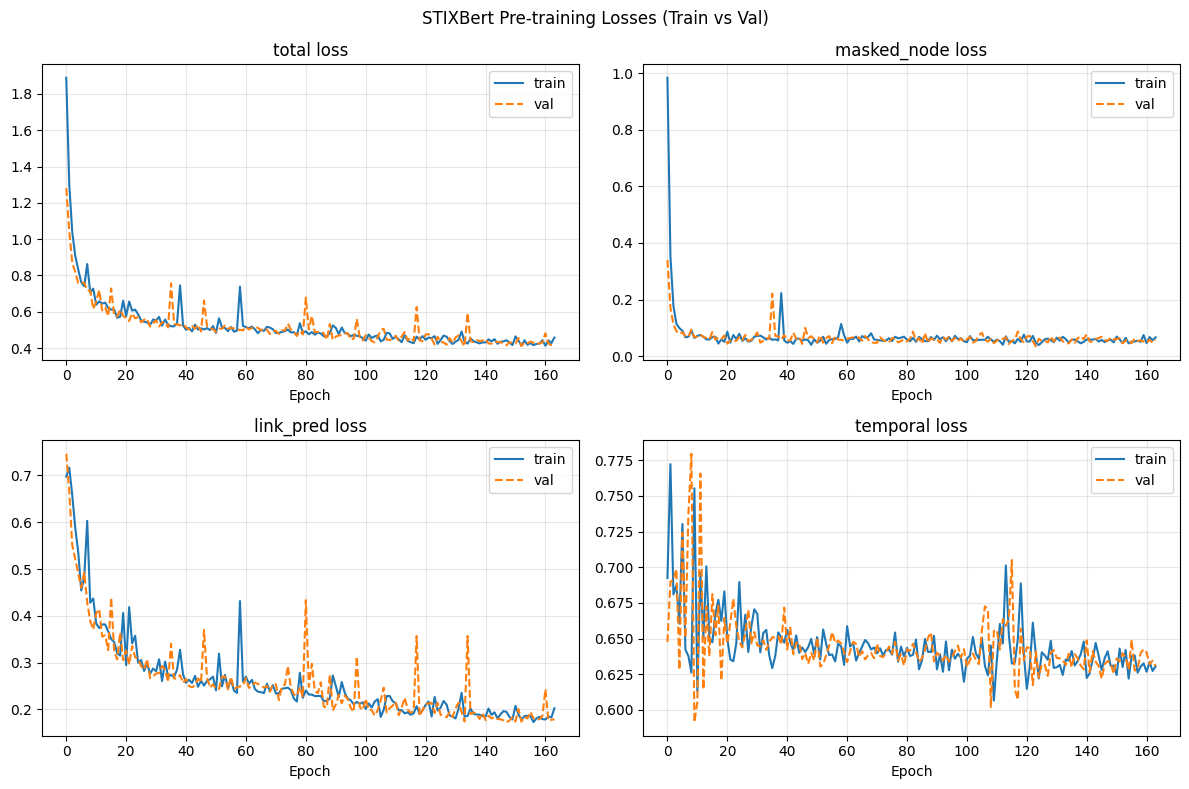

In [49]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, key in zip(axes.flatten(),
                   ['total', 'masked_node', 'link_pred', 'temporal']):
    ax.plot([h['train'][key] for h in history], label='train')
    ax.plot([h['val'][key] for h in history], label='val', linestyle='--')
    ax.set_title(f'{key} loss')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('STIXBert Pre-training Losses (Train vs Val)')
plt.tight_layout()
plt.savefig(
    str(PATHS['results'] / 'training_losses.png'),
    dpi=150, bbox_inches='tight',
)
plt.show()

## 6. Save Final Results

In [51]:
with open(PATHS['results'] / 'config.json', 'w') as f:
    json.dump(CFG, f, indent=2)

with open(PATHS['results'] / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

with open(PATHS['results'] / 'best_hyperparameters.json', 'w') as f:
    json.dump(best_hp, f, indent=2)

# hp_search_results.json is only available when Phase 1 actually ran
_hp_search_out = PATHS['results'] / 'hp_search_results.json'
if 'search_results' in dir():
    with open(_hp_search_out, 'w') as f:
        json.dump(search_results, f, indent=2, default=str)
elif not _hp_search_out.exists():
    print('  (hp_search_results.json skipped — Phase 1 was cached)')

print('Results saved (lightweight — no embeddings cached):')
for f in sorted((PATHS['results']).glob('*')):
    print(f'  {f.name}  ({f.stat().st_size / 1024:.1f} KB)')
print(f'  Best model: {PATHS["checkpoints"] / "stixbert_best.pt"}')

Results saved (lightweight — no embeddings cached):
  best_hyperparameters.json  (0.1 KB)
  campaign_clusters.png  (919.7 KB)
  config.json  (2.1 KB)
  cross_feed_overlap.png  (95.7 KB)
  feed_quality_scores.png  (51.3 KB)
  hp_search_results.json  (0.0 KB)
  label_efficiency.png  (136.1 KB)
  training_history.json  (62.3 KB)
  training_losses.png  (255.3 KB)
  Best model: /content/drive/MyDrive/stixbert/checkpoints/stixbert_best.pt


## 7. Push Model to HuggingFace Hub

`HF_TOKEN` is read from **Colab Secrets** (Key icon in sidebar).

In [52]:
import shutil
from huggingface_hub import HfApi, create_repo

# ── Reload saved state if runtime was restarted ──────────────────────
try:
    _ = CFG
except NameError:
    import os, torch
    from pathlib import Path
    from google.colab import drive
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive')
    DRIVE_ROOT = Path('/content/drive/MyDrive/stixbert')
    PATHS = {
        'raw_mitre':       DRIVE_ROOT / 'data/raw/mitre_attack',
        'raw_threatfox':   DRIVE_ROOT / 'data/raw/threatfox',
        'raw_digitalside': DRIVE_ROOT / 'data/raw/digitalside',
        'raw_urlhaus':     DRIVE_ROOT / 'data/raw/urlhaus',
        'raw_malwarebazaar': DRIVE_ROOT / 'data/raw/malwarebazaar',
        'raw_feodo':       DRIVE_ROOT / 'data/raw/feodo',
        'raw_cisa_kev':    DRIVE_ROOT / 'data/raw/cisa_kev',
        'processed':       DRIVE_ROOT / 'data/processed',
        'train':           DRIVE_ROOT / 'data/train',
        'test':            DRIVE_ROOT / 'data/test',
        'eval':            DRIVE_ROOT / 'data/eval',
        'checkpoints':     DRIVE_ROOT / 'checkpoints',
        'results':         DRIVE_ROOT / 'results',
    }
    with open(PATHS['results'] / 'config.json') as f:
        CFG = json.load(f)
    with open(PATHS['results'] / 'best_hyperparameters.json') as f:
        best_hp = json.load(f)
    with open(PATHS['results'] / 'training_history.json') as f:
        history = json.load(f)
    with open(PATHS['processed'] / 'graph_stats.json') as f:
        stats = json.load(f)
    data = torch.load(PATHS['processed'] / 'hetero_data.pt',
                      map_location='cpu', weights_only=False)
    ckpt = torch.load(PATHS['checkpoints'] / 'stixbert_best.pt',
                      map_location='cpu', weights_only=False)
    total_params = sum(p.numel() for p in ckpt['model'].values())
    del ckpt
    print('✓ Reloaded CFG, best_hp, history, stats, data from GDrive')

try:
    from google.colab import userdata
    hf_token = userdata.get('HF_TOKEN_W')
    print('HF_TOKEN loaded from Colab Secrets')
except (ImportError, userdata.SecretNotFoundError):
    raise RuntimeError(
        'HF_TOKEN not found. In Colab: Key icon -> Add HF_TOKEN.\n'
        'Get a token at: https://huggingface.co/settings/tokens',
    )

hf = CFG['huggingface']
repo_id = hf['repo_id']
upload_dir = Path('hf_upload')
upload_dir.mkdir(exist_ok=True)

# Copy artifacts
shutil.copy(
    PATHS['checkpoints'] / 'stixbert_best.pt',
    upload_dir / 'stixbert_best.pt',
)
with open(upload_dir / 'config.json', 'w') as f:
    json.dump(CFG, f, indent=2)
with open(upload_dir / 'graph_metadata.json', 'w') as f:
    json.dump({
        'node_types': data.node_types,
        'edge_types': [list(et) for et in data.edge_types],
        'graph_stats': stats,
        'best_hyperparameters': best_hp,
        'model_config': CFG['model'],
    }, f, indent=2)
shutil.copy(
    str(PATHS['results'] / 'best_hyperparameters.json'),
    upload_dir / 'best_hyperparameters.json',
)
shutil.copy(
    str(PATHS['results'] / 'training_history.json'),
    upload_dir / 'training_history.json',
)

# Model card
mc = CFG['model']
tc = CFG['training']
gs = CFG['grid_search']
cv_cfg = CFG['cv']
opt = CFG['optimization']
tags_yaml = '\n'.join(f'- {t}' for t in hf['tags'])

# Gather dynamic stats for the card
n_node_types = len(data.node_types)
n_edge_types = len(data.edge_types)
node_type_list = ', '.join(sorted(data.node_types))
edge_type_list = ', '.join(
    f'{s}-[{r}]->{d}' for s, r, d in sorted(data.edge_types))
total_nodes = sum(data[nt].num_nodes for nt in data.node_types)
total_edges = sum(data[et].edge_index.shape[1] for et in data.edge_types)
best_hp_md = '\n'.join(
    f'| `{k}` | {v} |' for k, v in sorted(best_hp.items()))
final_loss = history[-1]['val']['total'] if history else 'N/A'
final_mask = history[-1]['val']['masked_node'] if history else 'N/A'
final_link = history[-1]['val']['link_pred'] if history else 'N/A'
final_temp = history[-1]['val']['temporal'] if history else 'N/A'
n_epochs_ran = len(history)

model_card = f"""---
language: en
license: apache-2.0
library_name: pytorch
pipeline_tag: graph-ml
tags:
{tags_yaml}
---

# STIXBert — Self-Supervised STIX Graph Foundation Model

**STIXBert** is a Heterogeneous Graph Transformer (HGT) pre-trained with
self-supervised objectives on real-world STIX 2.1 threat-intelligence graphs.
It produces fixed-size embeddings for every node in a STIX bundle—indicators,
malware, attack-patterns, threat-actors, campaigns, and more—enabling
downstream tasks such as campaign clustering, ATT&CK technique classification,
cross-feed deduplication, infrastructure prediction, and feed quality scoring.

## Model Details

| Property | Value |
|----------|-------|
| Architecture | Heterogeneous Graph Transformer (HGT) |
| Layers | {mc['num_layers']} |
| Attention heads | {mc['num_heads']} |
| Hidden dimension | {mc['hidden_dim']} |
| Input dimension | {mc['input_dim']} |
| Output dimension | {mc['output_dim']} |
| Dropout | {mc['dropout']} |
| Parameters | **{total_params:,}** (~{total_params * 4 / 1024 / 1024:.1f} MB fp32) |
| Text encoder | `{mc['text_model']}` (max {mc['max_seq_length']} tokens) |
| Framework | PyTorch + PyTorch Geometric |

## Pre-training Objectives

STIXBert is trained with three complementary self-supervised losses:

1. **Masked Node Prediction** (weight {tc['loss_weights']['masked_node']}) —
   {int(tc['mask_ratio']*100)}% of node features are zeroed; the model
   reconstructs them via cosine-similarity loss.
2. **Link Prediction** (weight {tc['loss_weights']['link_pred']}) — binary
   cross-entropy on existing edges vs. sampled negatives.
3. **Temporal Ordering** (weight {tc['loss_weights']['temporal']}) — predict
   which of two nodes appeared first based on STIX timestamps.

## Training Procedure

### Phase 1 — Hyperparameter Search
- **Strategy:** Random search ({gs['n_trials']} trials)
- **CV:** {cv_cfg['num_folds']}-fold stratified by `{cv_cfg['stratify_by']}`
- **Search epochs per trial:** {gs['search_epochs']}
- **Swept parameters:** `{', '.join(gs['parameters'].keys())}`

### Phase 2 — Full Training with Best HPs
- **Max epochs:** {tc['num_epochs']} (early stopping patience={tc['early_stopping']['patience']})
- **Epochs completed:** {n_epochs_ran}
- **Optimizer:** {opt['optimizer'].upper()} (weight_decay={tc['weight_decay']})
- **Scheduler:** {opt['scheduler']} (warmup={opt['warmup_epochs']} epochs, min_lr={opt['min_lr']})
- **Gradient clipping:** {tc['grad_clip_norm']}
- **Mixed precision:** {'Yes' if opt['mixed_precision'] else 'No'}
- **Class imbalance:** {CFG['class_imbalance']['strategy']}

### Best Hyperparameters (from Phase 1)

| Parameter | Value |
|-----------|-------|
{best_hp_md}

### Final Training Losses (Epoch {n_epochs_ran})

| Loss | Value |
|------|-------|
| **Total** | {final_loss:.4f} |
| Masked Node | {final_mask:.4f} |
| Link Prediction | {final_link:.4f} |
| Temporal Ordering | {final_temp:.4f} |

## Training Data

| Statistic | Value |
|-----------|-------|
| Total nodes | {total_nodes:,} |
| Total edges | {total_edges:,} |
| Node types | {n_node_types} |
| Edge types | {n_edge_types} |

**Data sources:**
- **MITRE ATT&CK** — Enterprise, Mobile, ICS (STIX 2.1 bundles from
  `raw.githubusercontent.com/mitre-attack/attack-stix-data`)
- **ThreatFox** — Recent IOCs exported as STIX 2.1
  (`threatfox.abuse.ch/export/json/recent/`)
- **DigitalSide Threat-Intel** — Community STIX 2.1 bundles
  (`github.com/davidonzo/Threat-Intel`)

**Node types:** {node_type_list}

**Edge types:** {edge_type_list}

## Intended Uses

| Use Case | Description |
|----------|-------------|
| Campaign clustering | Group malware/indicators by embedding similarity; attribute new IOCs to known campaigns |
| ATT&CK classification | Fine-tune a linear head to predict MITRE ATT&CK tactics from node embeddings |
| Cross-feed deduplication | Identify near-duplicate indicators across feeds via cosine similarity |
| Infrastructure prediction | Predict which infrastructure a malware family will use next |
| Feed quality scoring | Score feed reliability by measuring embedding alignment with ATT&CK ground truth |

## Limitations

- Pre-trained on publicly available threat intel only; may not generalize to
  classified or proprietary feeds without fine-tuning.
- Graph structure depends on relationship quality in source data; missing or
  incorrect STIX relationships degrade embedding quality.
- Text features are encoded with `{mc['text_model']}` — very long descriptions
  are truncated to {mc['max_seq_length']} tokens.
- Node types not seen during pre-training will need the graph rebuilt with
  `include_scos=True` or additional SDO types.

## How to Use

```python
import torch
from huggingface_hub import hf_hub_download

# Download model + config
ckpt_path = hf_hub_download(repo_id='{hf['repo_id']}', filename='stixbert_best.pt')
cfg_path  = hf_hub_download(repo_id='{hf['repo_id']}', filename='config.json')
meta_path = hf_hub_download(repo_id='{hf['repo_id']}', filename='graph_metadata.json')

import json
with open(cfg_path) as f:
    cfg = json.load(f)
with open(meta_path) as f:
    meta = json.load(f)

# Rebuild model (paste STIXBert class or import from your code)
model = STIXBert(
    node_types=meta['node_types'],
    edge_types=[tuple(et) for et in meta['edge_types']],
    input_dim=cfg['model']['input_dim'],
    hidden_dim=meta['best_hyperparameters'].get('hidden_dim', cfg['model']['hidden_dim']),
    num_heads=meta['best_hyperparameters'].get('num_heads', cfg['model']['num_heads']),
    num_layers=meta['best_hyperparameters'].get('num_layers', cfg['model']['num_layers']),
    dropout=meta['best_hyperparameters'].get('dropout', cfg['model']['dropout']),
)
model.load_state_dict(torch.load(ckpt_path, map_location='cpu', weights_only=False))
model.eval()

# Get embeddings
embeddings = model.get_embeddings(x_dict, edge_index_dict)
```

## Citation

If you use STIXBert in your work, please cite:

```bibtex
@software{{stixbert2026,
  author = {{Dey, Shiladitya}},
  title  = {{STIXBert: Self-Supervised STIX Graph Foundation Model}},
  year   = {{2026}},
  url    = {{https://huggingface.co/{hf['repo_id']}}},
}}
```

## Repository

Source code and Colab notebook:
[github.com/sd1977/STIXBert](https://github.com/sd1977/STIXBert)
"""
(upload_dir / 'README.md').write_text(model_card)

# Push
api = HfApi(token=hf_token)
create_repo(
    repo_id=repo_id, private=hf.get('private', True),
    repo_type='model', exist_ok=True, token=hf_token,
)
api.upload_folder(
    folder_path=str(upload_dir), repo_id=repo_id,
    commit_message='STIXBert PoV checkpoint',
)
print(f'\nPushed to: https://huggingface.co/{repo_id}')
for f in sorted(upload_dir.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size / 1024 / 1024:.1f} MB)')
shutil.rmtree(upload_dir)

# ── Purge GDrive checkpoints (model is now on HF) ───────────────────
purge_dirs = [PATHS['checkpoints']]
purged_bytes = 0
for d in purge_dirs:
    if d.exists():
        for f in d.iterdir():
            purged_bytes += f.stat().st_size
            f.unlink()
        d.rmdir()
print(f'\nPurged {purged_bytes / 1024 / 1024:.1f} MB from GDrive')
print('Model lives on HuggingFace now — GDrive checkpoints removed.')

HF_TOKEN loaded from Colab Secrets


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...f_upload/stixbert_best.pt:   0%|          |  562kB /  305MB            


Pushed to: https://huggingface.co/shidey/stixbert
  README.md  (0.0 MB)
  best_hyperparameters.json  (0.0 MB)
  config.json  (0.0 MB)
  graph_metadata.json  (0.0 MB)
  stixbert_best.pt  (290.7 MB)
  training_history.json  (0.1 MB)

Purged 290.7 MB from GDrive
Model lives on HuggingFace now — GDrive checkpoints removed.
